In [31]:
import numpy as np

#n people, k cluster
def createClusteredData(n,k):
    np.random.seed(1234)
    pointsPerCluster = float(n)/k
    x = [] #Income and Age points(x,y)
    y = [] #The associated Cluster label
    for i in range (k): #Iterate through all the number of clusters 
        #Every CLuster Iteration gets their uniform distribution(ofcourse with random.seed(1234))
        # np.random.uniform(start, end)
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        ageCentroid = np.random.uniform(20.0, 70.0)

        #Every Cluster is considered to have same number of points
        #Iterate through those points
        for j in range(int(pointsPerCluster)):
            #x stores random normal distributions 
            # append one iteration on targetMean(centroid) and standardDeviations
            # + - 10000 in salary and + - 2 years in age
            x.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
            # y stores the cluster index as label 0,1,...k-1
            y.append(i)

        # convert both into np.array for performance
    x=np.array(x)
    y=np.array(y)
    return x,y


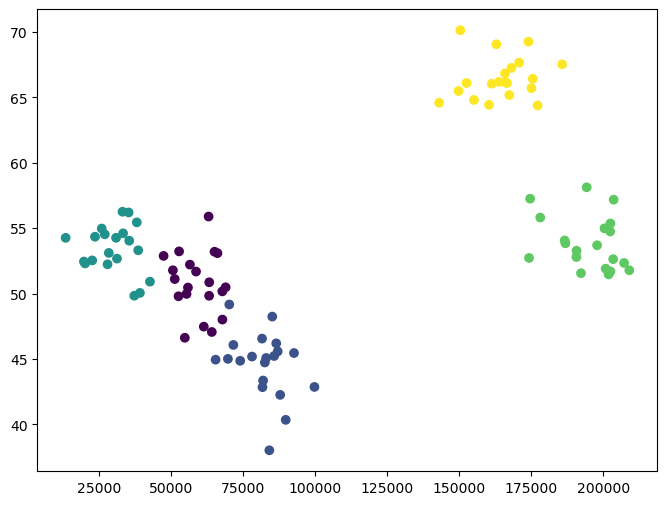

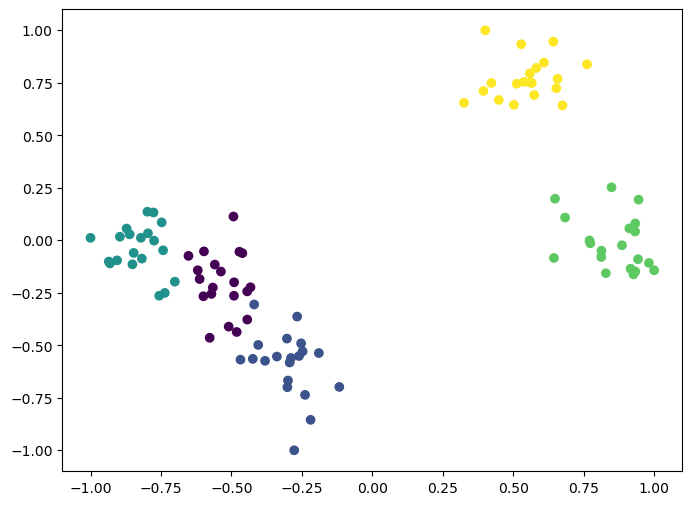

In [32]:
%matplotlib inline
from pylab import *
from sklearn.preprocessing import MinMaxScaler

# The function we wrote above returns us data to work on 
# as group of points stored in x and y stores the number of clusters
(x,y) = createClusteredData(100,5)


plt.figure(figsize=(8,6))
#Take the complete arrays in x with their array element's 
# first element as absicca and second element as ordinate 
# the index in y decide the colors of the respective clusters 
plt.scatter(x[:,0], x[:,1], c=y.astype(float))
plt.show()

# To scale it in a range for comparitive reasons
scaling = MinMaxScaler(feature_range=(-1,1)).fit(x)
x = scaling.transform(x)

plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], c=y.astype(float))
plt.show()


In [34]:
from sklearn import svm, datasets
C=1.0
#defualt kerner is 'abf'
svc = svm.SVC(kernel='linear', C=C).fit(x,y)

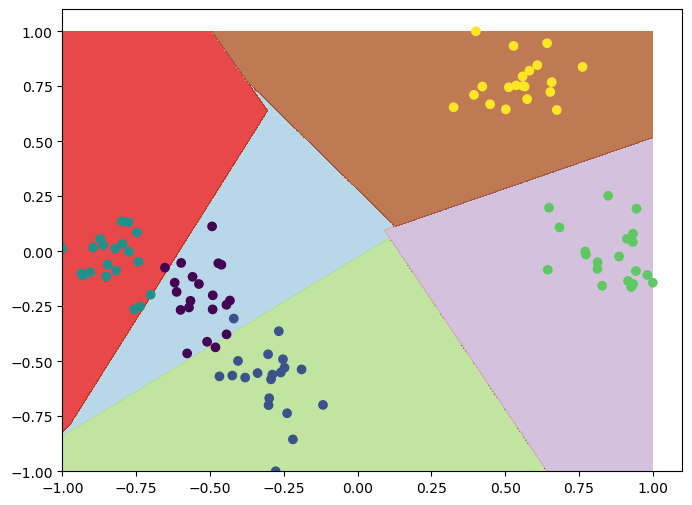

In [46]:
def plotPredictions(clf):
    # Make a grid where xx stores in row major order 
    # yy stores in column major order (the abscissa and ordinate)
    xx, yy = np.meshgrid(np.arange(-1, 1, .001),np.arange(-1, 1, .001))

    # coverte the grid into 1d array
    # if we output that we will get row major order
    npx = xx.ravel() #[-1, -0.999, ..., 0.999, -1, -0.999, ... , 0.999]
    npy = yy.ravel() #[-1, -1, -1, ...-0.999, -0.999, -0.999 ... , 0.999, 0.999]

    # Convert to list of coordinates along the column
    # c_[] for along the column and r_[] along the row
    samplePoints = np.c_[npx, npy]
    Z = clf.predict(samplePoints)
    
    plt.figure(figsize=(8,6))

    #changes shape of Z according to the grid's shape xx
    # xx.shape returns the shape of xx, rows x columns
    # reshape takes the row and column as argument and reshapes Z(predictions) 
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(x[:,0], x[:,1], c=y.astype(float))
    plt.show()
    
plotPredictions(svc)

In [51]:
# Make predictions on new data, first scale it
scaledData = scaling.transform([[200000,20]])
print(svc.predict(scaledData))

[1]
